# Linear Regression — Fundamentals 

## What is Linear Regression?

Linear Regression is one of the most fundamental algorithms in machine learning and statistics.  
Its goal is to model the **relationship between one or more input features (X)** and a **continuous numeric output (y)** by fitting a straight line (or hyperplane) through the data.

**Simple Linear Regression** (one feature):
$$\hat{y} = w_0 + w_1 \cdot x$$

- $w_0$ = **intercept** — where the line crosses the y-axis when x = 0  
- $w_1$ = **slope (coefficient)** — how much $\hat{y}$ changes for each unit increase in x

The algorithm finds the values of $w_0$ and $w_1$ that **minimise the sum of squared errors** between predictions and actual values — the *Ordinary Least Squares* (OLS) method.

---

## What we'll build

| Part | Topic |
|---|---|
| A | Simple Linear Regression: hours studied → exam score |
| B | Understanding coefficients, residuals, and fit quality (R²) |
| C | Multiple Linear Regression: salary prediction from experience + education |
| D | Assumptions check: residual plots |

## Step 1 — Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

plt.rcParams["figure.dpi"] = 110
print("Libraries loaded ✅")

Libraries loaded ✅


---
## Part A — Simple Linear Regression
### Scenario: Can we predict an exam score from hours studied?

We create 80 synthetic students whose exam scores follow a linear trend with added noise:
$$\text{score} = 50 + 4.5 \times \text{hours} + \epsilon$$
where $\epsilon \sim \mathcal{N}(0, 5)$ is random noise representing real-world variability.

In [2]:
n = 80
hours  = np.random.uniform(1, 10, n)                      # 1–10 hours studied
noise  = np.random.normal(0, 5, n)                        # realistic scatter
scores = 50 + 4.5 * hours + noise                         # true relationship
scores = np.clip(scores, 0, 100)                          # cap at 0-100

df = pd.DataFrame({"hours_studied": hours, "exam_score": scores})

print(df.describe().round(2))
df.head(8)

       hours_studied  exam_score
count          80.00       80.00
mean            5.19       73.27
std             2.75       13.80
min             1.05       46.97
25%             2.66       62.60
50%             4.92       72.85
75%             7.68       84.16
max             9.88      100.00


,hours_studied,exam_score
0,4.370861,71.325192
1,9.556429,97.881655
2,7.587945,81.749883
3,6.387926,77.817374
4,2.404168,55.287080
5,2.403951,54.836745
6,1.522753,60.915015
7,8.795585,96.361334


In [3]:
# ── Train / Test split ──────────────────────────────────────
X_simple = df[["hours_studied"]].values   # 2D array required by sklearn
y_simple = df["exam_score"].values

X_tr, X_te, y_tr, y_te = train_test_split(
    X_simple, y_simple, test_size=0.2, random_state=RANDOM_STATE
)

# ── Fit model ───────────────────────────────────────────────
lr_simple = LinearRegression()
lr_simple.fit(X_tr, y_tr)

w0 = lr_simple.intercept_          # bias / intercept
w1 = lr_simple.coef_[0]            # slope for hours_studied

print(f"Learned equation:  score = {w0:.2f} + {w1:.2f} × hours")
print(f"\nInterpretation:")
print(f"  • A student who studies 0 hours is predicted to score {w0:.1f}")
print(f"  • Each additional hour of study adds {w1:.2f} points to the predicted score")

Learned equation:  score = 49.04 + 4.63 × hours

Interpretation:
  • A student who studies 0 hours is predicted to score 49.0
  • Each additional hour of study adds 4.63 points to the predicted score


### Visualise the Regression Line

The blue line is the **fitted regression line** — the best single straight line through the training data.  
Each vertical red segment connecting a real point to the line is called a **residual** (prediction error).

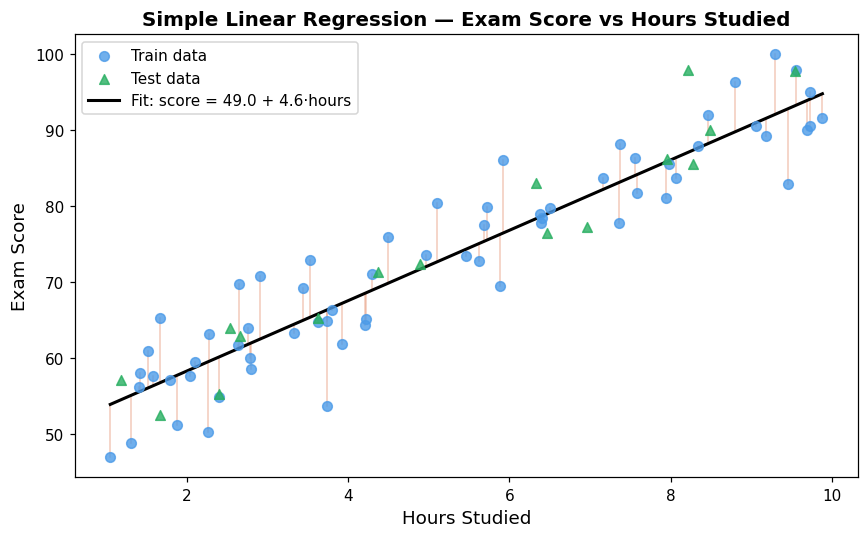

In [4]:
x_line = np.linspace(X_simple.min(), X_simple.max(), 200).reshape(-1, 1)
y_line = lr_simple.predict(x_line)

fig, ax = plt.subplots(figsize=(8, 5))

# Residuals (shown for training set only for clarity)
y_tr_pred = lr_simple.predict(X_tr)
for xi, yi_real, yi_pred in zip(X_tr.ravel(), y_tr, y_tr_pred):
    ax.plot([xi, xi], [yi_real, yi_pred], color="#e07b54", alpha=0.4, linewidth=1)

ax.scatter(X_tr, y_tr, color="#4c9be8", s=40, alpha=0.8, label="Train data", zorder=3)
ax.scatter(X_te, y_te, color="#27ae60", s=40, alpha=0.8, marker="^",
           label="Test data", zorder=3)
ax.plot(x_line, y_line, color="black", linewidth=2,
        label=f"Fit: score = {w0:.1f} + {w1:.1f}·hours")

ax.set_xlabel("Hours Studied", fontsize=12)
ax.set_ylabel("Exam Score", fontsize=12)
ax.set_title("Simple Linear Regression — Exam Score vs Hours Studied",
             fontsize=13, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

---
## Part B — Understanding Evaluation Metrics

| Metric | Formula | Meaning |
|---|---|---|
| **MAE** | $\frac{1}{n}\sum|y - \hat{y}|$ | Average absolute error in score units |
| **MSE** | $\frac{1}{n}\sum(y - \hat{y})^2$ | Penalises large errors more than MAE |
| **RMSE** | $\sqrt{MSE}$ | Same unit as target — easier to interpret |
| **R²** | $1 - \frac{SS_{res}}{SS_{tot}}$ | Fraction of variance explained (1.0 = perfect) |

**R² intuition:**  
- R² = 0.85 means the model explains 85% of the variance in exam scores.  
- R² = 0 means the model is no better than always predicting the mean.  
- R² < 0 means the model is worse than predicting the mean.

─── Test Set Metrics ───────────────────────────────
MAE  : 3.14  → predictions are off by 3.1 score points on average
MSE  : 15.89
RMSE : 3.99  → similar to MAE but penalises large misses more
R²   : 0.9199  → model explains 92.0% of score variance


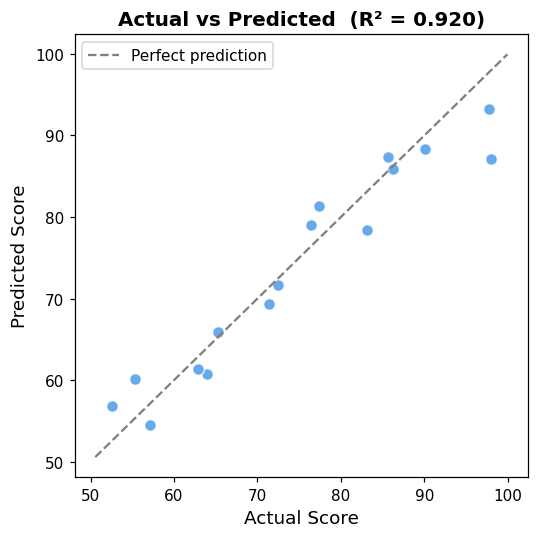

In [5]:
y_te_pred = lr_simple.predict(X_te)

mae  = mean_absolute_error(y_te, y_te_pred)
mse  = mean_squared_error(y_te, y_te_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_te, y_te_pred)

print("─── Test Set Metrics ───────────────────────────────")
print(f"MAE  : {mae:.2f}  → predictions are off by {mae:.1f} score points on average")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}  → similar to MAE but penalises large misses more")
print(f"R²   : {r2:.4f}  → model explains {r2*100:.1f}% of score variance")

# Plot actual vs predicted
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(y_te, y_te_pred, color="#4c9be8", edgecolors="white", s=60, alpha=0.85)
lims = [min(y_te.min(), y_te_pred.min()) - 2, max(y_te.max(), y_te_pred.max()) + 2]
ax.plot(lims, lims, "--", color="grey", linewidth=1.5, label="Perfect prediction")
ax.set_xlabel("Actual Score", fontsize=12)
ax.set_ylabel("Predicted Score", fontsize=12)
ax.set_title(f"Actual vs Predicted  (R² = {r2:.3f})", fontsize=13, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

---
## Part C — Multiple Linear Regression
### Scenario: Predicting annual salary from years of experience AND education level

Multiple Linear Regression extends the formula to multiple features:
$$\hat{y} = w_0 + w_1 x_1 + w_2 x_2 + \ldots + w_p x_p$$

Each coefficient $w_i$ tells you the **expected change in y for a one-unit increase in feature $i$**, holding all other features constant — this is called the **ceteris paribus** interpretation.

In [6]:
n = 120
experience    = np.random.uniform(0, 20, n)         # 0–20 years
education_yrs = np.random.randint(12, 22, n)        # 12–21 years of education
noise_sal     = np.random.normal(0, 3000, n)

# True relationship (known because we generated the data)
salary = (30_000
          + 2_500 * experience
          + 1_800 * education_yrs
          + noise_sal)

df_multi = pd.DataFrame({
    "experience_yrs": experience,
    "education_yrs":  education_yrs,
    "annual_salary":  salary,
})

print(df_multi.describe().round(0))
df_multi.head(6)

       experience_yrs  education_yrs  annual_salary
count           120.0          120.0          120.0
mean             11.0           17.0        85953.0
std               6.0            3.0        16556.0
min               0.0           12.0        52510.0
25%               6.0           14.0        74918.0
50%              11.0           16.0        86978.0
75%              16.0           19.0        98337.0
max              20.0           21.0       116574.0


,experience_yrs,education_yrs,annual_salary
0,18.493872,14,101976.158430
1,17.546787,18,109480.092241
2,5.158833,19,79390.516092
3,13.199681,15,86665.710863
4,16.344444,13,91673.264645
5,11.104016,21,97931.822548


In [7]:
X_multi = df_multi[["experience_yrs", "education_yrs"]].values
y_multi = df_multi["annual_salary"].values

X_tr2, X_te2, y_tr2, y_te2 = train_test_split(
    X_multi, y_multi, test_size=0.2, random_state=RANDOM_STATE
)

lr_multi = LinearRegression()
lr_multi.fit(X_tr2, y_tr2)

intercept = lr_multi.intercept_
coefs     = lr_multi.coef_

print("Learned equation:")
print(f"  salary = {intercept:,.0f}")
print(f"         + {coefs[0]:,.0f} × experience_yrs")
print(f"         + {coefs[1]:,.0f} × education_yrs")
print()
print("Interpretation:")
print(f"  • Each additional year of experience adds ~£{coefs[0]:,.0f} to predicted salary")
print(f"  • Each additional year of education adds ~£{coefs[1]:,.0f} to predicted salary")

Learned equation:
  salary = 29,383
         + 2,505 × experience_yrs
         + 1,809 × education_yrs

Interpretation:
  • Each additional year of experience adds ~£2,505 to predicted salary
  • Each additional year of education adds ~£1,809 to predicted salary


─── Multiple Regression — Test Metrics ────────────
MAE  : £1,910
RMSE : £2,477
R²   : 0.9820  → 98.2% of salary variance explained


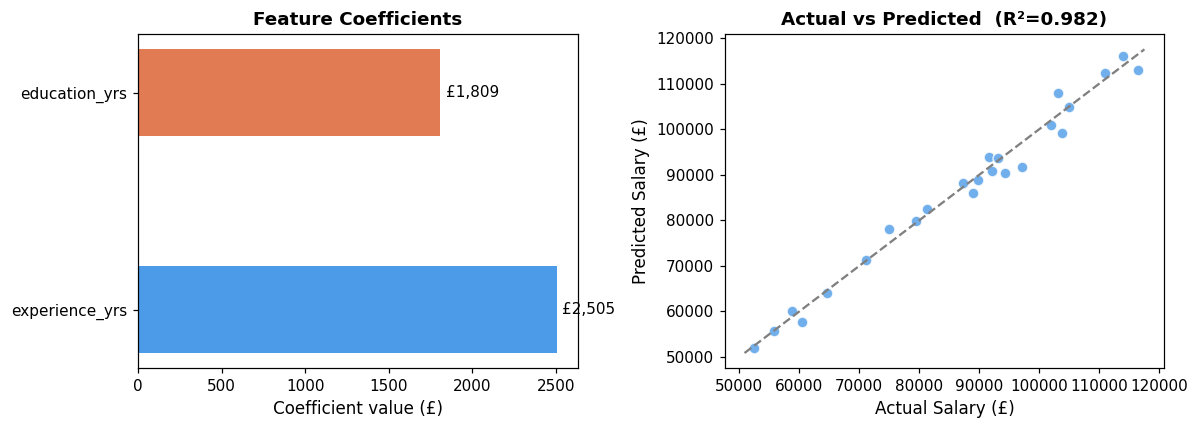

In [8]:
y_te2_pred = lr_multi.predict(X_te2)

mae2  = mean_absolute_error(y_te2, y_te2_pred)
rmse2 = np.sqrt(mean_squared_error(y_te2, y_te2_pred))
r2_2  = r2_score(y_te2, y_te2_pred)

print("─── Multiple Regression — Test Metrics ────────────")
print(f"MAE  : £{mae2:,.0f}")
print(f"RMSE : £{rmse2:,.0f}")
print(f"R²   : {r2_2:.4f}  → {r2_2*100:.1f}% of salary variance explained")

# Coefficient comparison chart
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Left: coefficient magnitudes
features = ["experience_yrs", "education_yrs"]
axes[0].barh(features, coefs, color=["#4c9be8", "#e07b54"], height=0.4)
axes[0].set_xlabel("Coefficient value (£)", fontsize=11)
axes[0].set_title("Feature Coefficients", fontsize=12, fontweight="bold")
for i, v in enumerate(coefs):
    axes[0].text(v + 30, i, f"£{v:,.0f}", va="center", fontsize=10)

# Right: actual vs predicted
axes[1].scatter(y_te2, y_te2_pred, color="#4c9be8", alpha=0.8,
                edgecolors="white", s=50)
lims2 = [min(y_te2.min(), y_te2_pred.min()) - 1000,
          max(y_te2.max(), y_te2_pred.max()) + 1000]
axes[1].plot(lims2, lims2, "--", color="grey", linewidth=1.5)
axes[1].set_xlabel("Actual Salary (£)", fontsize=11)
axes[1].set_ylabel("Predicted Salary (£)", fontsize=11)
axes[1].set_title(f"Actual vs Predicted  (R²={r2_2:.3f})",
                  fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()

---
## Part D — Assumptions Check: Residual Analysis

Linear Regression has four key assumptions:

1. **Linearity** — the relationship between X and y is linear  
2. **Independence** — residuals are independent of each other  
3. **Homoscedasticity** — residuals have constant variance (no funnel shape)  
4. **Normality of residuals** — residuals follow a normal distribution  

We check assumptions 1, 3, and 4 with plots below.

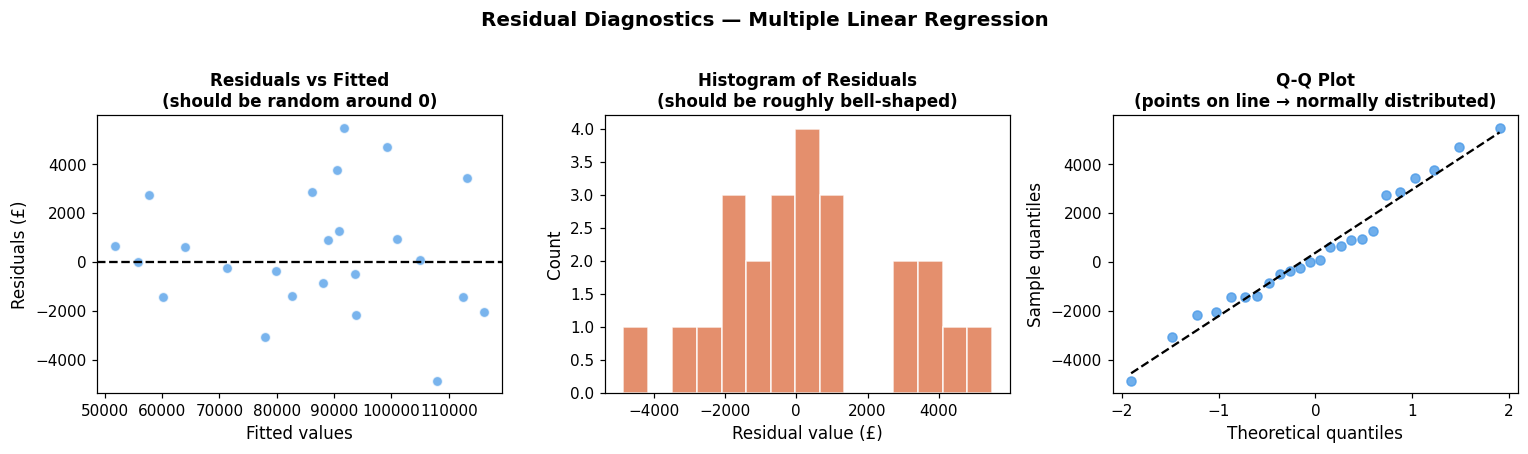

In [9]:
residuals = y_te2 - y_te2_pred

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# ── Plot 1: Residuals vs Fitted ──────────────────────────────
# Good: random scatter around 0  |  Bad: a curve or funnel shape
axes[0].scatter(y_te2_pred, residuals, color="#4c9be8", alpha=0.75,
                edgecolors="white", s=45)
axes[0].axhline(0, color="black", linewidth=1.5, linestyle="--")
axes[0].set_xlabel("Fitted values", fontsize=11)
axes[0].set_ylabel("Residuals (£)", fontsize=11)
axes[0].set_title("Residuals vs Fitted\n(should be random around 0)",
                  fontsize=11, fontweight="bold")

# ── Plot 2: Histogram of residuals ──────────────────────────
# Good: bell-shaped (normal)  |  Bad: skewed or multimodal
axes[1].hist(residuals, bins=15, color="#e07b54", edgecolor="white", alpha=0.85)
axes[1].set_xlabel("Residual value (£)", fontsize=11)
axes[1].set_ylabel("Count", fontsize=11)
axes[1].set_title("Histogram of Residuals\n(should be roughly bell-shaped)",
                  fontsize=11, fontweight="bold")

# ── Plot 3: Q-Q plot ─────────────────────────────────────────
# Points close to the diagonal line → residuals are normally distributed
from scipy import stats
(osm, osr), (slope, intercept_qq, r) = stats.probplot(residuals, dist="norm")
axes[2].scatter(osm, osr, color="#4c9be8", alpha=0.8, s=35)
axes[2].plot(osm, slope * np.array(osm) + intercept_qq,
             color="black", linewidth=1.5, linestyle="--")
axes[2].set_xlabel("Theoretical quantiles", fontsize=11)
axes[2].set_ylabel("Sample quantiles", fontsize=11)
axes[2].set_title("Q-Q Plot\n(points on line → normally distributed)",
                  fontsize=11, fontweight="bold")

plt.suptitle("Residual Diagnostics — Multiple Linear Regression",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## Summary

| Concept | Key Point |
|---|---|
| Equation | $\hat{y} = w_0 + w_1 x_1 + \ldots$ — a weighted sum of features plus bias |
| Fitting | OLS minimises sum of squared residuals |
| Intercept | Value of $\hat{y}$ when all features are 0 |
| Coefficient | Change in $\hat{y}$ for +1 unit in that feature, all else held constant |
| R² | Proportion of variance explained — higher is better (max 1.0) |
| RMSE | Average error in the same units as y — easier to interpret than MSE |
| Residuals | Actual − Predicted — diagnosing their distribution checks assumptions |
